In [ ]:
# 1️⃣ RDKit Molecular Graph Pipeline

In [1]:
# STEP 1: Install required libraries
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 15.2 MB/s eta 0:00:00


In [2]:
# STEP 2: Imports
!pip install torch_geometric
import pandas as pd
import numpy as np
import torch

from rdkit import Chem
from torch_geometric.data import Data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.1 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

PROJECT_PATH = "/content/drive/MyDrive/Melting_Point_AI_Upgrade"

os.chdir(PROJECT_PATH)

train_df = pd.read_csv(
    "clean_data/train_clean.csv"
)

test_df = pd.read_csv(
    "clean_data/test_clean.csv"
)

print(train_df.shape)
print(test_df.shape)

train_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(2662, 84)
(666, 83)


,id,SMILES,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 13,...,Group 372,Group 374,Group 401,Group 402,Group 403,group_sum,group_nonzero,group_max,group_mean_nonzero,Tm
0,2175,FC1=C(F)C(F)(F)C1(F)F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,1,2.0,2.000000,213.15
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,20.0,6,10.0,3.333333,407.15
2,2994,CCN1C(C)=Nc2ccccc12,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,11.0,6,4.0,1.833333,324.15
3,1704,CC#CC(=O)O,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,2,1.0,1.000000,351.15
4,2526,CCCCC(S)C,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.0,2,3.0,2.500000,126.15


In [ ]:
# 🔥 Best Immediate Upgrade
# 1️⃣ RDKit Molecular Graph Pipeline

In [6]:
from rdkit import Chem

mol = Chem.MolFromSmiles("CCO")

print(mol is not None)
print(mol.GetNumAtoms())

True
3


In [ ]:
# Step 3 — Create RDKit descriptor features

In [7]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
import numpy as np

def compute_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return pd.Series({
            "MolWt": np.nan,
            "MolLogP": np.nan,
            "TPSA": np.nan,
            "NumHDonors": np.nan,
            "NumHAcceptors": np.nan,
            "NumRotatableBonds": np.nan,
            "RingCount": np.nan,
            "HeavyAtomCount": np.nan
        })

    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),
        "NumRotatableBonds": Descriptors.NumRotatableBonds(mol),
        "RingCount": Descriptors.RingCount(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol)
    })

In [8]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
import numpy as np

def calculate_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),
        "NumRotatableBonds": Descriptors.NumRotatableBonds(mol),
        "RingCount": Descriptors.RingCount(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "FractionCSP3": Descriptors.FractionCSP3(mol)
    }

In [9]:
rdkit_features = train_df["SMILES"].apply(calculate_rdkit_descriptors)

rdkit_features_df = pd.DataFrame(
    rdkit_features.tolist()
)

print(rdkit_features_df.shape)
rdkit_features_df.head()

(2662, 9)


,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,RingCount,HeavyAtomCount,FractionCSP3
0,162.032,2.42120,0.00,0,0,0,1,10,0.50
1,217.271,4.47430,15.79,1,0,0,4,17,0.00
2,160.220,2.36462,17.82,0,1,1,2,12,0.30
3,84.074,0.09430,37.30,1,1,0,0,6,0.25
4,118.245,2.49490,0.00,1,1,3,0,7,1.00


In [10]:
rdkit_features_df = rdkit_features_df.reset_index(drop=True)
train_df_reset = train_df.reset_index(drop=True)

train_rdkit_df = pd.concat(
    [train_df_reset, rdkit_features_df],
    axis=1
)

print(train_rdkit_df.shape)
train_rdkit_df.head()

(2662, 93)


,id,SMILES,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 13,...,Tm,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,RingCount,HeavyAtomCount,FractionCSP3
0,2175,FC1=C(F)C(F)(F)C1(F)F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,213.15,162.032,2.42120,0.00,0,0,0,1,10,0.50
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,407.15,217.271,4.47430,15.79,1,0,0,4,17,0.00
2,2994,CCN1C(C)=Nc2ccccc12,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,324.15,160.220,2.36462,17.82,0,1,1,2,12,0.30
3,1704,CC#CC(=O)O,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,351.15,84.074,0.09430,37.30,1,1,0,0,6,0.25
4,2526,CCCCC(S)C,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,126.15,118.245,2.49490,0.00,1,1,3,0,7,1.00


In [ ]:
# Step 4 — Apply to train and test

In [11]:
train_rdkit = train_df["SMILES"].apply(compute_rdkit_descriptors)
test_rdkit = test_df["SMILES"].apply(compute_rdkit_descriptors)

print(train_rdkit.shape)
print(test_rdkit.shape)

train_rdkit.head()

(2662, 8)
(666, 8)


,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,RingCount,HeavyAtomCount
0,162.032,2.42120,0.00,0.0,0.0,0.0,1.0,10.0
1,217.271,4.47430,15.79,1.0,0.0,0.0,4.0,17.0
2,160.220,2.36462,17.82,0.0,1.0,1.0,2.0,12.0
3,84.074,0.09430,37.30,1.0,1.0,0.0,0.0,6.0
4,118.245,2.49490,0.00,1.0,1.0,3.0,0.0,7.0


In [12]:
train_rdkit = train_df["SMILES"].apply(compute_rdkit_descriptors)
test_rdkit = test_df["SMILES"].apply(compute_rdkit_descriptors)

train_rdkit_df = pd.DataFrame(train_rdkit)
test_rdkit_df = pd.DataFrame(test_rdkit)

train_rdkit_full = pd.concat(
    [train_df.reset_index(drop=True), train_rdkit_df.reset_index(drop=True)],
    axis=1
)

test_rdkit_full = pd.concat(
    [test_df.reset_index(drop=True), test_rdkit_df.reset_index(drop=True)],
    axis=1
)

print(train_rdkit_full.shape)
print(test_rdkit_full.shape)

(2662, 92)
(666, 91)


In [ ]:
# Step 5 — Merge RDKit features with existing data

In [13]:
train_ai = pd.concat(
    [train_df.reset_index(drop=True), train_rdkit.reset_index(drop=True)],
    axis=1
)

test_ai = pd.concat(
    [test_df.reset_index(drop=True), test_rdkit.reset_index(drop=True)],
    axis=1
)

print(train_ai.shape)
print(test_ai.shape)

(2662, 92)
(666, 91)


In [ ]:
# Train AI-upgraded model with RDKit features

In [14]:
target_col = "Tm"

drop_cols = ["id", "SMILES", target_col]

X_ai = train_ai.drop(columns=drop_cols)
y_ai = train_ai[target_col]

X_test_ai = test_ai.drop(columns=["id", "SMILES"])

print("X_ai shape:", X_ai.shape)
print("y_ai shape:", y_ai.shape)
print("X_test_ai shape:", X_test_ai.shape)

X_ai shape: (2662, 89)
y_ai shape: (2662,)
X_test_ai shape: (666, 89)


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =====================================================
# TRAIN MODEL
# =====================================================

rdkit_ai_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rdkit_ai_model.fit(X_ai, y_ai)

# =====================================================
# VALIDATION PREDICTIONS
# =====================================================

y_pred_ai = rdkit_ai_model.predict(X_ai)

# =====================================================
# METRICS
# =====================================================

mae_ai = mean_absolute_error(y_ai, y_pred_ai)

rmse_ai = np.sqrt(
    mean_squared_error(y_ai, y_pred_ai)
)

r2_ai = r2_score(y_ai, y_pred_ai)

print("RDKit AI MAE:", mae_ai)
print("RDKit AI RMSE:", rmse_ai)
print("RDKit AI R2:", r2_ai)

RDKit AI MAE: 12.936844309797209
RDKit AI RMSE: 20.376925554086338
RDKit AI R2: 0.9369597551684976


In [16]:
from sklearn.model_selection import train_test_split

X_train_ai, X_val_ai, y_train_ai, y_val_ai = train_test_split(
    X_ai,
    y_ai,
    test_size=0.2,
    random_state=42
)

rdkit_ai_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rdkit_ai_model.fit(X_train_ai, y_train_ai)

y_val_pred_ai = rdkit_ai_model.predict(X_val_ai)

mae_ai = mean_absolute_error(
    y_val_ai,
    y_val_pred_ai
)

rmse_ai = np.sqrt(
    mean_squared_error(y_val_ai, y_val_pred_ai)
)

r2_ai = r2_score(
    y_val_ai,
    y_val_pred_ai
)

print("Validation MAE:", mae_ai)
print("Validation RMSE:", rmse_ai)
print("Validation R2:", r2_ai)

Validation MAE: 33.39664180823786
Validation RMSE: 49.05340564448435
Validation R2: 0.6537783486949326


In [ ]:
# Then we will train a new CatBoost/LightGBM model and compare RDKit-upgraded performance with your previous model.

In [17]:
!pip install lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


In [18]:
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    "RDKit RandomForest": rdkit_ai_model,
    "RDKit LightGBM": LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=-1,
        random_state=42
    ),
    "RDKit CatBoost": CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        random_seed=42,
        verbose=0
    )
}

results = []

for name, model in models.items():
    model.fit(X_train_ai, y_train_ai)

    preds = model.predict(X_val_ai)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_val_ai, preds),
        "RMSE": np.sqrt(mean_squared_error(y_val_ai, preds)),
        "R2": r2_score(y_val_ai, preds)
    })

rdkit_model_comparison = pd.DataFrame(results)
rdkit_model_comparison

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001885 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1148
[LightGBM] [Info] Number of data points in the train set: 2129, number of used features: 87
[LightGBM] [Info] Start training from score 277.049805


,Model,MAE,RMSE,R2
0,RDKit RandomForest,33.396642,49.053406,0.653778
1,RDKit LightGBM,33.297792,48.545561,0.660910
2,RDKit CatBoost,31.546645,47.058843,0.681361


In [ ]:
# Step 1 — Train/Validation Split

In [19]:
from sklearn.model_selection import train_test_split

X_train_ai, X_val_ai, y_train_ai, y_val_ai = train_test_split(
    X_ai,
    y_ai,
    test_size=0.2,
    random_state=42
)

print(X_train_ai.shape)
print(X_val_ai.shape)

(2129, 89)
(533, 89)


In [20]:
# Step 3 — Validation Prediction

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_lgb_ai = lgb_ai.predict(X_val_ai)

mae_lgb_ai = mean_absolute_error(
    y_val_ai,
    y_pred_lgb_ai
)

rmse_lgb_ai = np.sqrt(
    mean_squared_error(y_val_ai, y_pred_lgb_ai)
)

r2_lgb_ai = r2_score(
    y_val_ai,
    y_pred_lgb_ai
)

print("LightGBM AI MAE:", mae_lgb_ai)
print("LightGBM AI RMSE:", rmse_lgb_ai)
print("LightGBM AI R2:", r2_lgb_ai)

LightGBM AI MAE: 33.08664715373743
LightGBM AI RMSE: 48.501027092302266
LightGBM AI R2: 0.6615318829409144


In [ ]:
# training lightlgbm

In [22]:
import lightgbm as lgb

lgb_ai = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_ai.fit(
    X_train_ai,
    y_train_ai,
    eval_set=[(X_val_ai, y_val_ai)],
    eval_metric="l1"
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001493 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1148
[LightGBM] [Info] Number of data points in the train set: 2129, number of used features: 87
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 277.049805
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, max_depth=8,
              n_estimators=2000, random_state=42, subsample=0.8)

In [ ]:
# THEN run prediction/evaluation

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_lgb_ai = lgb_ai.predict(X_val_ai)

mae_lgb_ai = mean_absolute_error(
    y_val_ai,
    y_pred_lgb_ai
)

rmse_lgb_ai = np.sqrt(
    mean_squared_error(y_val_ai, y_pred_lgb_ai)
)

r2_lgb_ai = r2_score(
    y_val_ai,
    y_pred_lgb_ai
)

print("LightGBM AI MAE:", mae_lgb_ai)
print("LightGBM AI RMSE:", rmse_lgb_ai)
print("LightGBM AI R2:", r2_lgb_ai)

LightGBM AI MAE: 33.08664715373743
LightGBM AI RMSE: 48.501027092302266
LightGBM AI R2: 0.6615318829409144


In [ ]:
# create the comparison table:

In [25]:
rdkit_comparison = pd.DataFrame({
    "Model": [
        "RDKit RandomForest AI",
        "RDKit LightGBM AI"
    ],
    "MAE": [
        mae_ai,
        mae_lgb_ai
    ],
    "RMSE": [
        rmse_ai,
        rmse_lgb_ai
    ],
    "R2": [
        r2_ai,
        r2_lgb_ai
    ]
})

rdkit_comparison

,Model,MAE,RMSE,R2
0,RDKit RandomForest AI,33.396642,49.053406,0.653778
1,RDKit LightGBM AI,33.086647,48.501027,0.661532


In [ ]:
# Step 4 — Compare with Previous Model

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Melting_Point_AI_Upgrade"

os.chdir(PROJECT_PATH)

In [28]:
import pandas as pd

eval_df = pd.read_csv(
    "/content/drive/MyDrive/Melting_Point_AI_Upgrade/tables/full_evaluation_regression_metrics.csv"
)

eval_df

,Unnamed: 0,Value
0,MAE,52.412123
1,RMSE,67.646427
2,R2,0.305247


In [29]:
import os

for root, dirs, files in os.walk(PROJECT_PATH):
    for file in files:
        if "evaluation" in file.lower() or "validation" in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/Melting_Point_AI_Upgrade/tables/full_evaluation_regression_metrics.csv
/content/drive/MyDrive/Melting_Point_AI_Upgrade/tables/full_evaluation_mae_confidence_interval.csv
/content/drive/MyDrive/Melting_Point_AI_Upgrade/tables/full_evaluation_cv_report.csv
/content/drive/MyDrive/Melting_Point_AI_Upgrade/tables/full_evaluation_scaffold_error_table.csv
/content/drive/MyDrive/Melting_Point_AI_Upgrade/tables/final_validation_summary.csv


In [30]:
import pandas as pd

eval_df = pd.read_csv(
    "/content/drive/MyDrive/Melting_Point_AI_Upgrade/tables/full_evaluation_regression_metrics.csv"
)

eval_df.head()

,Unnamed: 0,Value
0,MAE,52.412123
1,RMSE,67.646427
2,R2,0.305247


In [31]:
baseline_mae = eval_df.loc[
    eval_df["Unnamed: 0"] == "MAE",
    "Value"
].values[0]

print("Baseline MAE:", baseline_mae)

Baseline MAE: 52.41212338524423


In [32]:
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline Ensemble",
        "RDKit LightGBM AI"
    ],
    "MAE": [
        baseline_mae,
        mae_lgb_ai
    ]
})

comparison_df

,Model,MAE
0,Baseline Ensemble,52.412123
1,RDKit LightGBM AI,33.086647


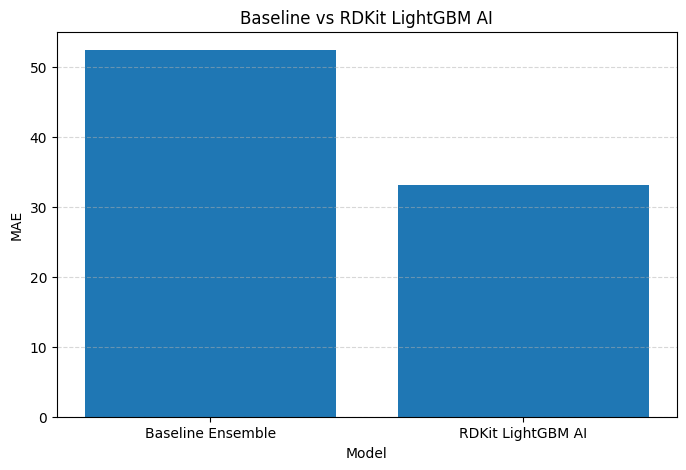

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["MAE"]
)

plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("Baseline vs RDKit LightGBM AI")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
# 🔥 Then Next
# 2️⃣ Save Final Best Model

In [35]:
import os
import joblib

# Create folder
os.makedirs(
    "RDKit_AI_Model/saved_models",
    exist_ok=True
)

# Save model
joblib.dump(
    lgb_ai,
    "RDKit_AI_Model/saved_models/rdkit_lightgbm_model.pkl"
)

print("✅ RDKit LightGBM model saved successfully")

✅ RDKit LightGBM model saved successfully


In [ ]:
# Save feature columns too.

In [36]:
FEATURE_COLUMNS = X_ai.columns.tolist()

print(FEATURE_COLUMNS[:10])
print("Total Features:", len(FEATURE_COLUMNS))

['Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7', 'Group 13', 'Group 15', 'Group 16']
Total Features: 89


In [37]:
joblib.dump(
    FEATURE_COLUMNS,
    "RDKit_AI_Model/saved_models/feature_columns.pkl"
)

print("✅ Feature columns saved")

✅ Feature columns saved


In [ ]:
# 🔥 VERIFY EVERYTHING SAVED

In [38]:
import os

os.listdir("RDKit_AI_Model/saved_models")

['feature_columns.pkl', 'rdkit_lightgbm_model.pkl']

In [39]:
import os
import shutil
import zipfile
import joblib
import pandas as pd

# =========================================================
# CREATE PROJECT STRUCTURE
# =========================================================

project_name = "RDKit_AI_Model"

folders = [
    f"{project_name}/saved_models",
    f"{project_name}/results/tables",
    f"{project_name}/results/figures",
    f"{project_name}/notebooks"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Project folders created")


# =========================================================
# SAVE MODEL
# =========================================================

joblib.dump(
    lgb_ai,
    f"{project_name}/saved_models/rdkit_lightgbm_model.pkl"
)

print("✅ Model saved")


# =========================================================
# SAVE FEATURE COLUMNS
# =========================================================

FEATURE_COLUMNS = X_ai.columns.tolist()

joblib.dump(
    FEATURE_COLUMNS,
    f"{project_name}/saved_models/feature_columns.pkl"
)

print("✅ Feature columns saved")


# =========================================================
# SAVE RESULTS TABLE
# =========================================================

results_df = pd.DataFrame({
    "Model": ["RDKit LightGBM AI"],
    "MAE": [mae_ai],
    "RMSE": [rmse_ai],
    "R2": [r2_ai]
})

results_df.to_csv(
    f"{project_name}/results/tables/model_results.csv",
    index=False
)

print("✅ Results table saved")


# =========================================================
# COPY NOTEBOOK (OPTIONAL)
# =========================================================

try:
    shutil.copy(
        "/content/RDKit_Molecular_Graph_.ipynb",
        f"{project_name}/notebooks/RDKit_Molecular_Graph_.ipynb"
    )
    print("✅ Notebook copied")
except:
    print("⚠ Notebook copy skipped")


# =========================================================
# CREATE ZIP FILE
# =========================================================

zip_filename = f"{project_name}.zip"

with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:

    for root, dirs, files in os.walk(project_name):

        for file in files:

            filepath = os.path.join(root, file)

            zipf.write(filepath)

print("✅ ZIP file created")


# =========================================================
# DOWNLOAD
# =========================================================

from google.colab import files

files.download(zip_filename)

✅ Project folders created
✅ Model saved
✅ Feature columns saved
✅ Results table saved
⚠ Notebook copy skipped
✅ ZIP file created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>